<a href="https://colab.research.google.com/github/Laizem/CN_Lab/blob/master/Jeeny_Faprotax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FAPROTAX** with *Plotting*

---



## **Instructions**:


1.  Click the "Play" button on Step 1 below. A "Choose Files" button will appear.

2.  Select and upload ALL THREE of these files at the exact same time:

    *  Your raw data table (.tsv)

    * FAPROTAX.txt

    * collapse_table.py

3.  Once the uploads hit 100% and it says "Verified and ready", click the "Play" button on Step 2 below.

4.  Scroll down to see and download your plots!

## **Step 1**



In [6]:
# --- STEP 1: UPLOAD FILES SEQUENTIALLY ---
from google.colab import files
import os

def safe_upload(target_name, prompt_msg):
    print(f"\n{prompt_msg}")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print(f"❌ You cancelled the upload. Please stop the cell and try again.")
        return False

    # Get the actual name Colab saved the file as
    uploaded_name = list(uploaded.keys())[0]

    # If the target file already exists from a previous run, delete it to ensure a clean overwrite
    if os.path.exists(target_name) and uploaded_name != target_name:
        os.remove(target_name)

    # Rename whatever they uploaded to the exact name the pipeline requires
    if uploaded_name != target_name:
        os.rename(uploaded_name, target_name)

    print(f"✅ Successfully loaded and set as: {target_name}")
    return True

print("--- FILE UPLOAD SEQUENCE ---")

# Prompt 1: The Data Table
success1 = safe_upload(
    'FAPROTAX_input.tsv',
    "👇 1. Click 'Choose Files' to upload your DATA TABLE (.tsv) 👇"
)

if success1:
    # Prompt 2: The TXT Database
    success2 = safe_upload(
        'FAPROTAX.txt',
        "👇 2. Click 'Choose Files' to upload the DATABASE (FAPROTAX.txt) 👇"
    )

if success1 and success2:
    # Prompt 3: The Python Script
    success3 = safe_upload(
        'collapse_table.py',
        "👇 3. Click 'Choose Files' to upload the SCRIPT (collapse_table.py) 👇"
    )

if success1 and success2 and success3:
    print("\n🎉 ALL 3 FILES READY! You can now click play on Step 2.")
else:
    print("\n❌ Pipeline paused due to a missing file. Please rerun this step.")

--- FILE UPLOAD SEQUENCE ---

👇 1. Click 'Choose Files' to upload your DATA TABLE (.tsv) 👇


Saving otu_taxon.tsv to otu_taxon (1).tsv
✅ Successfully loaded and set as: FAPROTAX_input.tsv

👇 2. Click 'Choose Files' to upload the DATABASE (FAPROTAX.txt) 👇


Saving FAPROTAX.txt to FAPROTAX.txt
✅ Successfully loaded and set as: FAPROTAX.txt

👇 3. Click 'Choose Files' to upload the SCRIPT (collapse_table.py) 👇


Saving collapse_table.py to collapse_table.py
✅ Successfully loaded and set as: collapse_table.py

🎉 ALL 3 FILES READY! You can now click play on Step 2.


## **Step 2**

2. Generating plots...



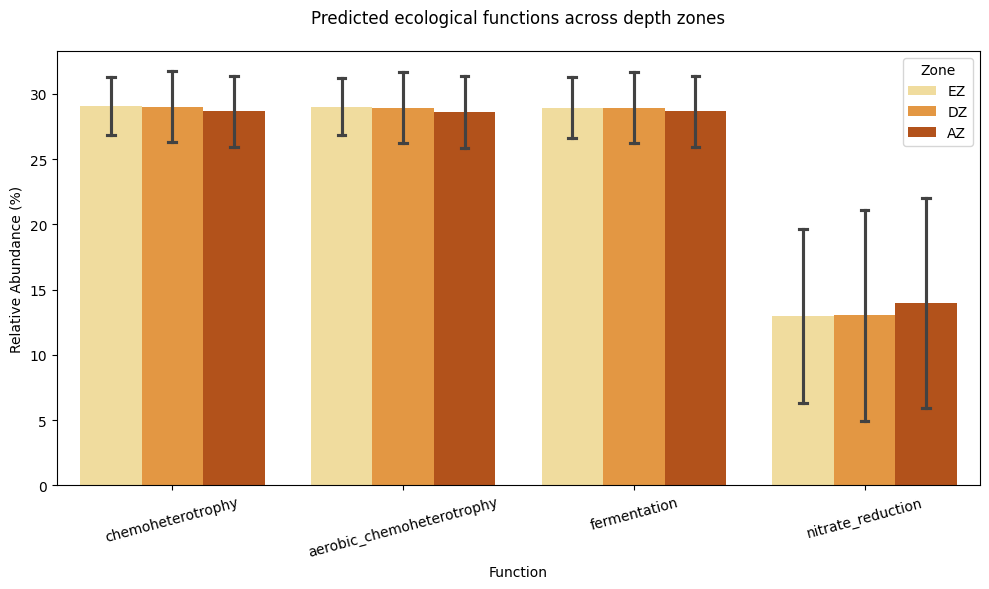

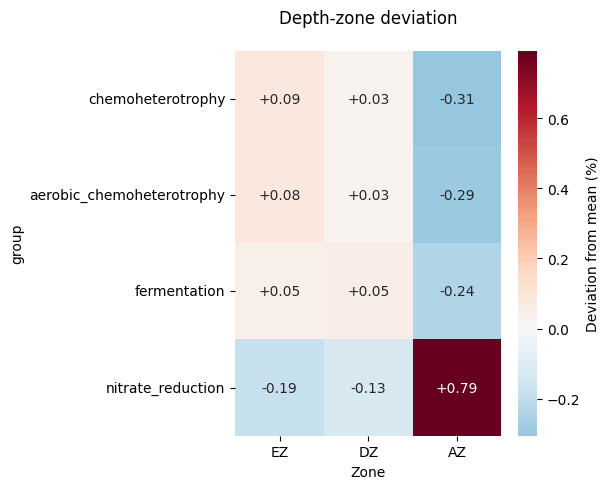


✅ Success! Downloading high-res images to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# --- STEP 2: RUN ANALYSIS & GENERATE PLOTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from IPython.display import clear_output

print("1. Processing microbial functions using your uploaded FAPROTAX files...")
# Run the script directly from the uploaded files
!python collapse_table.py -i FAPROTAX_input.tsv -o functional_table.tsv -g FAPROTAX.txt -d taxonomy > /dev/null 2>&1

clear_output()

print("2. Generating plots...\n")

# LOAD DATA
try:
    df = pd.read_csv('functional_table.tsv', sep='\t', index_col='group')
except FileNotFoundError:
    print("❌ Error: functional_table.tsv was not created. Ensure your input file has a 'taxonomy' column!")
    exit()

cols_to_drop = [c for c in df.columns if 'Unnamed' in c or c == 'OTU']
df = df.drop(columns=cols_to_drop)

# EXTRACT ZONES
metadata = {}
for col in df.columns:
    match = re.search(r'_(\d+)m', col)
    if match:
        depth = int(match.group(1))
        if depth <= 215: zone = 'EZ'
        elif depth <= 1000: zone = 'DZ'
        else: zone = 'AZ'
        metadata[col] = zone

df = df[list(metadata.keys())]
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

# CALCULATE RELATIVE ABUNDANCE
df_rel = df.div(df.sum(axis=0), axis=1) * 100
df_rel = df_rel.fillna(0)

target_functions = ['chemoheterotrophy', 'aerobic_chemoheterotrophy', 'fermentation', 'nitrate_reduction']
available_funcs = [f for f in target_functions if f in df_rel.index]

if not available_funcs:
    print("❌ Error: Target functions not found in the output.")
else:
    df_subset = df_rel.loc[available_funcs]
    df_transposed = df_subset.T
    df_transposed['Zone'] = df_transposed.index.map(metadata)
    df_melted = df_transposed.melt(id_vars=['Zone'], var_name='Function', value_name='Relative Abundance (%)')
    zone_order = ['EZ', 'DZ', 'AZ']

    # --- PLOT A: BAR CHART ---
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x='Function', y='Relative Abundance (%)', hue='Zone', hue_order=zone_order, palette='YlOrBr', capsize=0.1, errorbar='sd')
    plt.title("Predicted ecological functions across depth zones", pad=20)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('plot_A_barplot.png', dpi=300)
    plt.show()

    # --- PLOT B: HEATMAP ---
    zone_means = df_transposed.groupby('Zone')[available_funcs].mean()
    global_means = df_subset.mean(axis=1)
    deviation_matrix = zone_means.sub(global_means, axis=1).T
    deviation_matrix = deviation_matrix[[z for z in zone_order if z in deviation_matrix.columns]]

    plt.figure(figsize=(6, 5))
    sns.heatmap(deviation_matrix, cmap='RdBu_r', center=0, annot=True, fmt="+.2f", cbar_kws={'label': 'Deviation from mean (%)'})
    plt.title("Depth-zone deviation", pad=20)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('plot_B_heatmap.png', dpi=300)
    plt.show()

    from google.colab import files
    print("\n✅ Success! Downloading high-res images to your computer...")
    try:
        files.download('plot_A_barplot.png')
        files.download('plot_B_heatmap.png')
    except Exception as e:
        print("Note: Could not auto-download. Click the folder icon on the left to download your images manually.")